# Experiment 5: ResNet50 Fine-tuned + Class Weights

## Hypothesis

In all three transfer experiments, the trash class recall plateaued at 0.81,
regardless of architecture or fine-tuning. This confirmed that the bottleneck
is data imbalance (trash: 453 images vs clothes: 1892), not feature quality.

This experiment applies inverse-frequency class weights to the best model
so far (ResNet50 two-phase fine-tuning, 93.29%). The loss for minority
classes is up-weighted (trash 2.7x, biological 1.75x, battery 1.62x).

Expected outcome: improved recall on minority classes (especially trash),
possibly at a small cost to overall accuracy — a precision-recall trade-off.

## Configuration

Identical to Experiment 3, with one change: class_weight applied in both phases.
- Phase 1: frozen base, lr=1e-3, class weights ON
- Phase 2: unfroze conv5_block3, lr=1e-5, class weights ON

In [4]:
import os
import shutil

if os.path.exists('trash-classification'):
    shutil.rmtree('trash-classification')

!git clone https://github.com/wayofell/trash-classification.git
%cd trash-classification

import sys
sys.path.insert(0, '.')

import tensorflow as tf
print(f"TF version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

Cloning into 'trash-classification'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 91 (delta 37), reused 76 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 5.50 MiB | 23.09 MiB/s, done.
Resolving deltas: 100% (37/37), done.
/kaggle/working/trash-classification
TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from src.data import load_dataset, get_class_weights, CLASS_NAMES, NUM_CLASSES
from src.model import build_resnet50_transfer, unfreeze_last_block
from src.train import compile_and_train, evaluate_on_test, get_default_callbacks
from src.utils import (
    log_experiment, plot_training_curves,
    collect_predictions, plot_confusion_matrix, print_classification_report,
    get_experiments_dir
)

print("All imports OK")

All imports OK


In [7]:
BATCH_SIZE = 32

train_ds, val_ds, test_ds, sizes = load_dataset(batch_size=BATCH_SIZE)

# Compute class weights
class_weights = get_class_weights()

print("Dataset sizes:")
for split, n in sizes.items():
    print(f"  {split:5s}: {n:>5d} samples")

print("\nClass weights to apply:")
for idx, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:11s} ({idx}): {class_weights[idx]:.3f}")

Dataset sizes:
  train:  8593 samples
  val  :  1833 samples
  test :  1833 samples

Class weights to apply:
  battery     (0): 1.622
  biological  (1): 1.754
  cardboard   (2): 0.869
  clothes     (3): 0.648
  glass       (4): 0.706
  metal       (5): 1.318
  paper       (6): 0.918
  plastic     (7): 0.768
  shoes       (8): 0.846
  trash       (9): 2.706


## Phase 1: Classifier head with class weights

In [9]:
model = build_resnet50_transfer(trainable_base=False)

PHASE1_EPOCHS = 15
PHASE1_LR = 1e-3

history_p1, time_p1 = compile_and_train(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=PHASE1_EPOCHS,
    learning_rate=PHASE1_LR,
    optimizer_name="adam",
    class_weight=class_weights,   # <-- the key change
    verbose=2,
)

print(f"\nPhase 1 finished in {time_p1:.1f} sec ({time_p1/60:.1f} min)")
print(f"Phase 1 best val_accuracy: {max(history_p1.history['val_accuracy']):.4f}")

Epoch 1/15
269/269 - 47s - 173ms/step - accuracy: 0.7910 - loss: 0.6730 - val_accuracy: 0.8914 - val_loss: 0.3337 - learning_rate: 1.0000e-03
Epoch 2/15
269/269 - 14s - 52ms/step - accuracy: 0.8933 - loss: 0.3193 - val_accuracy: 0.9056 - val_loss: 0.2958 - learning_rate: 1.0000e-03
Epoch 3/15
269/269 - 14s - 52ms/step - accuracy: 0.9117 - loss: 0.2649 - val_accuracy: 0.8947 - val_loss: 0.3223 - learning_rate: 1.0000e-03
Epoch 4/15
269/269 - 14s - 52ms/step - accuracy: 0.9205 - loss: 0.2302 - val_accuracy: 0.9171 - val_loss: 0.2690 - learning_rate: 1.0000e-03
Epoch 5/15
269/269 - 14s - 52ms/step - accuracy: 0.9287 - loss: 0.2044 - val_accuracy: 0.9089 - val_loss: 0.2992 - learning_rate: 1.0000e-03
Epoch 6/15
269/269 - 14s - 52ms/step - accuracy: 0.9374 - loss: 0.1805 - val_accuracy: 0.9160 - val_loss: 0.2764 - learning_rate: 1.0000e-03
Epoch 7/15

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
269/269 - 14s - 52ms/step - accuracy: 0.9372 - loss: 0.1747 - val

## Phase 2: Unfreeze last block, keep class weights

In [11]:
import time

n_unfrozen = unfreeze_last_block(model, block_name="conv5_block3")
print(f"Layers unfrozen: {n_unfrozen}")

PHASE2_LR = 1e-5
PHASE2_EPOCHS = 20

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE2_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

callbacks_p2 = get_default_callbacks(
    early_stopping_patience=7,
    lr_reduce_patience=4,
)

start = time.time()
history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_p2,
    class_weight=class_weights,   # <-- key change here too
    verbose=2,
)
time_p2 = time.time() - start

print(f"\nPhase 2 finished in {time_p2:.1f} sec ({time_p2/60:.1f} min)")
print(f"Phase 2 best val_accuracy: {max(history_p2.history['val_accuracy']):.4f}")

Layers unfrozen: 7
Epoch 1/20
269/269 - 35s - 132ms/step - accuracy: 0.9871 - loss: 0.0347 - val_accuracy: 0.9318 - val_loss: 0.2809 - learning_rate: 1.0000e-05
Epoch 2/20
269/269 - 15s - 57ms/step - accuracy: 0.9893 - loss: 0.0300 - val_accuracy: 0.9362 - val_loss: 0.2676 - learning_rate: 1.0000e-05
Epoch 3/20
269/269 - 15s - 57ms/step - accuracy: 0.9905 - loss: 0.0275 - val_accuracy: 0.9378 - val_loss: 0.2746 - learning_rate: 1.0000e-05
Epoch 4/20
269/269 - 15s - 57ms/step - accuracy: 0.9909 - loss: 0.0274 - val_accuracy: 0.9345 - val_loss: 0.2897 - learning_rate: 1.0000e-05
Epoch 5/20
269/269 - 15s - 57ms/step - accuracy: 0.9909 - loss: 0.0238 - val_accuracy: 0.9351 - val_loss: 0.2852 - learning_rate: 1.0000e-05
Epoch 6/20

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
269/269 - 15s - 57ms/step - accuracy: 0.9935 - loss: 0.0180 - val_accuracy: 0.9411 - val_loss: 0.2802 - learning_rate: 1.0000e-05
Epoch 7/20
269/269 - 15s - 57ms/step - accuracy: 0.9957 -

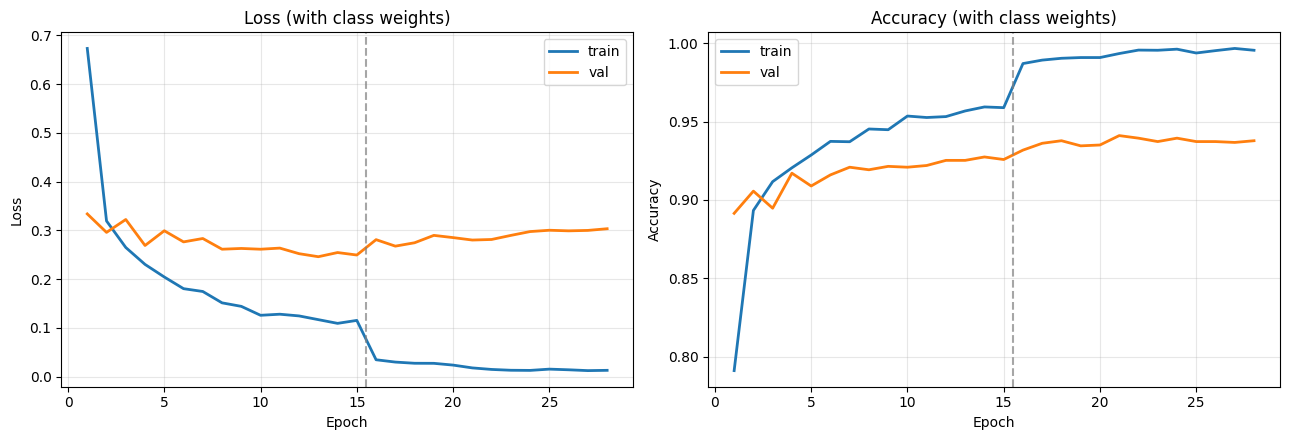

In [12]:
import matplotlib.pyplot as plt

def combine_histories(*histories):
    combined = {}
    for h in histories:
        for k, v in h.history.items():
            combined.setdefault(k, []).extend(v)
    return combined

combined = combine_histories(history_p1, history_p2)
phase1_end = len(history_p1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs_total = range(1, len(combined['loss']) + 1)

axes[0].plot(epochs_total, combined['loss'], label='train', linewidth=2)
axes[0].plot(epochs_total, combined['val_loss'], label='val', linewidth=2)
axes[0].axvline(phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss (with class weights)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_total, combined['accuracy'], label='train', linewidth=2)
axes[1].plot(epochs_total, combined['val_accuracy'], label='val', linewidth=2)
axes[1].axvline(phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy (with class weights)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plots_dir = get_experiments_dir() / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(plots_dir / "05_resnet50_classweights_curves.png", bbox_inches='tight', dpi=150)
plt.show()

In [13]:
test_loss, test_acc = evaluate_on_test(model, test_ds)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"\n--- Comparison ---")
print(f"ResNet50 fine-tuned (no weights):    93.29%")
print(f"ResNet50 fine-tuned + class weights: {test_acc * 100:.2f}%")
print(f"Difference: {(test_acc - 0.9329) * 100:+.2f} pp")

Test loss:     0.2306
Test accuracy: 0.9351 (93.51%)

--- Comparison ---
ResNet50 fine-tuned (no weights):    93.29%
ResNet50 fine-tuned + class weights: 93.51%
Difference: +0.22 pp


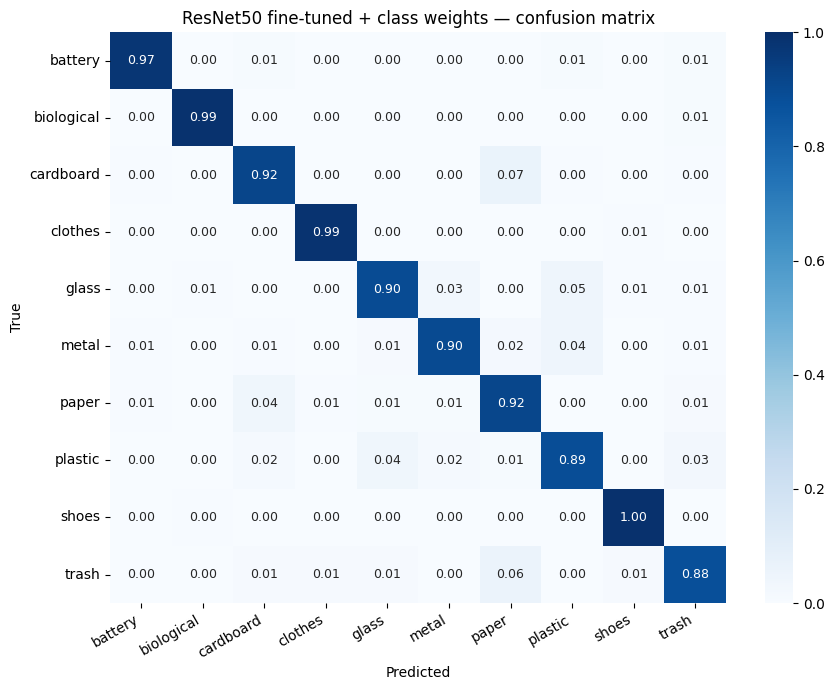

In [14]:
y_true, y_pred = collect_predictions(model, test_ds)

cm = plot_confusion_matrix(
    y_true, y_pred,
    class_names=CLASS_NAMES,
    title="ResNet50 fine-tuned + class weights — confusion matrix",
    normalize=True,
    save_path=plots_dir / "05_resnet50_classweights_confusion.png"
)

In [15]:
from sklearn.metrics import f1_score

report = print_classification_report(y_true, y_pred, CLASS_NAMES)
macro_f1 = f1_score(y_true, y_pred, average="macro")

print(f"\nMacro F1: {macro_f1:.4f}")
print(f"vs ResNet50 fine-tuned no-weights (0.9248): {(macro_f1 - 0.9248):+.4f}")

# Focus on minority classes
print(f"\n--- Minority class recall comparison ---")
print(f"{'class':12s} {'no_weights':>11s} {'now':>8s}")
print("-" * 35)
baseline_recall = {  # from Experiment 3 (no weights)
    'trash': 0.806, 'biological': 0.981, 'battery': 0.982,
    'metal': 0.885,
}
for cls in ['trash', 'battery', 'biological', 'metal']:
    idx = CLASS_NAMES.index(cls)
    cls_recall = report[cls]['recall']
    print(f"{cls:12s} {baseline_recall[cls]:>11.3f} {cls_recall:>8.3f}")

              precision    recall  f1-score   support

     battery      0.973     0.973     0.973       113
  biological      0.972     0.990     0.981       104
   cardboard      0.924     0.919     0.922       211
     clothes      0.993     0.986     0.989       283
       glass      0.940     0.896     0.917       260
       metal      0.893     0.899     0.896       139
       paper      0.888     0.915     0.901       200
     plastic      0.910     0.887     0.898       239
       shoes      0.977     0.995     0.986       217
       trash      0.787     0.881     0.831        67

    accuracy                          0.935      1833
   macro avg      0.926     0.934     0.930      1833
weighted avg      0.936     0.935     0.935      1833


Macro F1: 0.9296
vs ResNet50 fine-tuned no-weights (0.9248): +0.0048

--- Minority class recall comparison ---
class         no_weights      now
-----------------------------------
trash              0.806    0.881
battery            0.982 

In [24]:
total_epochs = len(history_p1.history['loss']) + len(history_p2.history['loss'])
total_time = time_p1 + time_p2

log_experiment({
    "experiment_name": "05_resnet50_finetune_classweights",
    "model": "resnet50_imagenet_finetune_lastblock",
    "epochs": total_epochs,
    "batch_size": BATCH_SIZE,
    "optimizer": "adam",
    "learning_rate": f"{PHASE1_LR}->{PHASE2_LR}",
    "augmentation": "flip+brightness+contrast",
    "class_weights": "inverse_frequency",   # <-- the difference
    "train_acc": round(history_p2.history['accuracy'][-1], 4),
    "val_acc": round(max(history_p2.history['val_accuracy']), 4),
    "test_acc": round(test_acc, 4),
    "test_macro_f1": round(macro_f1, 4),
    "train_loss": round(history_p2.history['loss'][-1], 4),
    "val_loss": round(min(history_p2.history['val_loss']), 4),
    "test_loss": round(test_loss, 4),
    "training_time_sec": round(total_time, 1),
    "notes": "same as exp 3 but WITH inverse-frequency class weights",
})

import pandas as pd
df = pd.read_csv(get_experiments_dir() / "results.csv")
print(df.to_string(index=False))

          timestamp                   experiment_name                                model  epochs  batch_size optimizer learning_rate             augmentation     class_weights  train_acc  val_acc  test_acc  test_macro_f1  train_loss  val_loss  test_loss  training_time_sec                                                  notes
2026-05-20T14:41:49 05_resnet50_finetune_classweights resnet50_imagenet_finetune_lastblock      28          32      adam  0.001->1e-05 flip+brightness+contrast inverse_frequency     0.9956   0.9411    0.9351         0.9296       0.013    0.2676     0.2306              462.4 same as exp 3 but WITH inverse-frequency class weights


## Findings

### Overall performance — new best model
- ResNet50 fine-tuned + class weights: **93.51%** test accuracy
- vs no weights (93.29%): **+0.22 pp** — both accuracy AND macro F1 improved
- Macro F1: **0.930** (vs 0.9248, **+0.0048**)
- This is the best model in the project so far

### Class weights broke the trash ceiling
The trash class recall had plateaued at 0.81 across three previous transfer
experiments (ResNet50 frozen, fine-tuned, EfficientNetV2S), independent of
architecture. Class weights finally moved it:

| Metric          | No weights | With weights | Δ      |
|-----------------|-----------|--------------|--------|
| trash recall    | 0.806     | 0.881        | +0.075 |
| trash precision | 0.806     | 0.787        | -0.019 |
| trash F1        | 0.806     | 0.831        | +0.025 |

The recall gain at a small precision cost is the expected behavior of class
weighting: the model becomes more willing to predict the minority class.
For a waste-sorting application, higher trash recall is desirable (better to
catch more actual trash).

### Minimal trade-off on majority classes
Unlike typical class-weighting outcomes, majority classes barely degraded:
- glass: -0.016, plastic: -0.008, battery: -0.009 (all minor)
- paper: +0.025, metal: +0.014, biological: +0.009 (several improved)

The net effect is positive because the weights were moderate (inverse
frequency, trash 2.7x) rather than aggressive. This preserved majority-class
performance while boosting minorities.

### Comparison across all experiments

| # | Model                          | Test Acc | Macro F1 | trash recall |
|---|--------------------------------|----------|----------|--------------|
| 1 | Baseline CNN                   | 78.61%   | 0.780    | 0.582        |
| 2 | ResNet50 frozen                | 92.69%   | 0.920    | 0.806        |
| 3 | ResNet50 fine-tuned            | 93.29%   | 0.925    | 0.806        |
| 4 | EfficientNetV2S frozen         | 92.53%   | 0.919    | 0.806        |
| 5 | ResNet50 fine-tuned + weights  | 93.51%   | 0.930    | 0.881        |

## Discussion

Class weighting was the single most effective intervention for the minority
class, validating the diagnosis from EDA and the three transfer experiments:
the trash bottleneck was a data imbalance problem, not a feature or
architecture problem. The fact that overall accuracy also improved (rather
than degrading, as class weighting often does) makes this the clear best
configuration for the task.